# Phase 4 Legacy Runner (Price + Sentiment)

This notebook runs the **original/non-improved** Phase 4 script:
- `phase4_price_sentiment_ppo_legacy.py`

Outputs are saved to:
- `results/phase4_price_sentiment_legacy/`


In [1]:
# Optional installs
# %pip install gymnasium stable-baselines3 matplotlib


In [2]:
import subprocess
import sys
from pathlib import Path
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False


In [3]:
# Run config
TIMESTEPS = 50_000
SEED = 42
RESULTS_DIR = Path("results/phase4_price_sentiment_legacy")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
# Run legacy script
cmd = [
    sys.executable,
    "phase4_price_sentiment_ppo_legacy.py",
    "--timesteps", str(TIMESTEPS),
    "--seed", str(SEED),
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)


Running: /usr/local/bin/python3 phase4_price_sentiment_ppo_legacy.py --timesteps 50000 --seed 42
Using PPO params from: results/phase4_tuning/best_params_price_sentiment.json
Num features (price+sentiment): 22
PPO params: {'learning_rate': 0.00014312907952658717, 'n_steps': 512, 'batch_size': 512, 'n_epochs': 10, 'gamma': 0.995, 'gae_lambda': 0.9, 'ent_coef': 0.001, 'vf_coef': 0.75, 'clip_range': 0.3}
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2378 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2292        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.005027357 |
|    clip_fraction        | 0.00

CompletedProcess(args=['/usr/local/bin/python3', 'phase4_price_sentiment_ppo_legacy.py', '--timesteps', '50000', '--seed', '42'], returncode=0)

In [5]:
# Load legacy metrics
metrics_path = RESULTS_DIR / "phase4_price_sentiment_metrics.csv"
metrics_df = pd.read_csv(metrics_path)
metrics_df


,strategy,cumulative_return_pct,ann_sharpe,ann_sortino,max_drawdown_pct,win_rate,alpha_vs_xph_ann_pct
0,BuyHold_Equal,9.625921,0.377820,0.613220,-17.925456,0.508982,7.737318
1,EqualWeight_Monthly,8.460957,0.339634,0.554942,-18.982354,0.500998,7.237284
2,PPO_PriceSentiment,-2.700687,0.001324,0.002046,-18.387630,0.483034,2.205872
3,XPH,-8.074730,-0.090723,-0.145941,-22.619079,0.491018,0.000000
4,Momentum_20D,-8.401114,-0.171261,-0.254539,-24.221550,0.465070,-0.998788


In [6]:
# Load legacy Phase3 vs Phase4 comparison
comp_path = RESULTS_DIR / "phase3_vs_phase4_comparison.csv"
if comp_path.exists():
    comp_df = pd.read_csv(comp_path)
    display(comp_df)
else:
    print("Comparison file not found:", comp_path)


,metric,phase3_price_only,phase4_price_sentiment,delta_p4_minus_p3
0,cumulative_return_pct,12.106765,-2.700687,-14.807452
1,ann_sharpe,0.445379,0.001324,-0.444055
2,ann_sortino,0.718082,0.002046,-0.716037
3,max_drawdown_pct,-15.215891,-18.387630,-3.171740
4,alpha_vs_xph_ann_pct,9.152787,2.205872,-6.946915


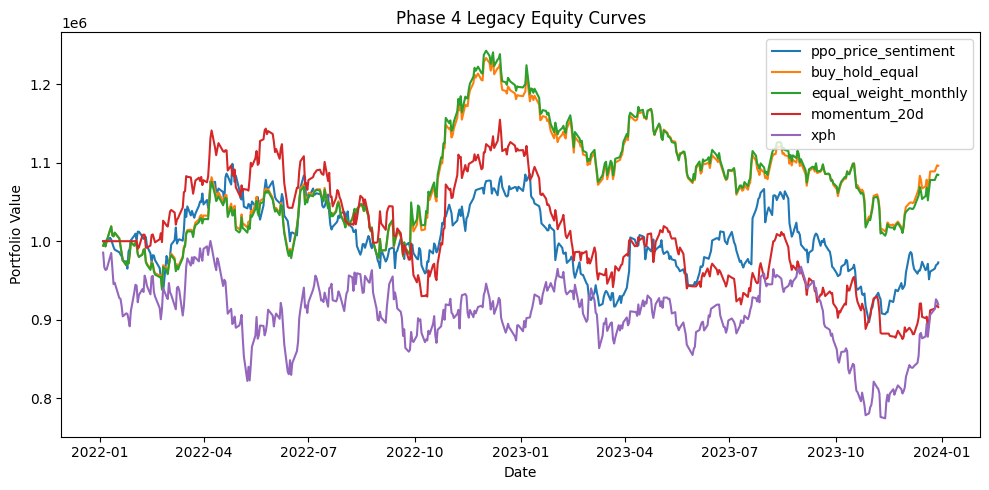

In [7]:
# Optional equity curve plot
curve_path = RESULTS_DIR / "phase4_price_sentiment_equity_curve.csv"
if HAS_MATPLOTLIB and curve_path.exists():
    cdf = pd.read_csv(curve_path, parse_dates=["date"])
    plt.figure(figsize=(10,5))
    for c in ["ppo_price_sentiment","buy_hold_equal","equal_weight_monthly","momentum_20d","xph"]:
        if c in cdf.columns:
            plt.plot(cdf["date"], cdf[c], label=c)
    plt.title("Phase 4 Legacy Equity Curves")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped (matplotlib missing or curve file not found).")
